# Influence of `mu = rho * N1 / d0` on viability signal fidelity

`mu` is the mean number of HEK cells transfected per sequence -- `rho` (HEK cells per plasmid)
times `N1` (plasmids sampled per round) divided by `d0` (library diversity). It's the SAME
derived quantity `plot_topk_recovery_heatmap` (`analysisV1.py`) draws as contour lines over its
`(N1, rho)` heatmap; this notebook instead sweeps `mu` directly and asks: **does the correlation
between the TRUE viability score and the NGS-measured viability log enrichment (`target1`)
depend only on `mu`, or do `rho`/`N1` matter separately beyond their product?**

**Design.** For each `mu` in a log-spaced grid, 10 simulation runs: 5 different `(rho, N1)` pairs
that all solve `rho * N1 / d0 = mu` (`rho` spread ~1.4 decades apart, `N1` computed to compensate
-- this is the "does the split matter" axis) x 2 independent stochastic repeats each (fresh `jax`
randomness -- this is the "average out simulation noise" axis) = 5x2 = 10 runs per `mu`, averaged
into one `r(mu)` point.

**Reused from `Protocol_parameters_and_first_classic_use.ipynb`** for direct comparability: the
same real AAV9 `F_viab`/`J_viab`, the same `F_sel`/`J_sel` (built from the same two permutation
keys), the same fixed 20,000-sequence pool. `mu ~ 25` at that notebook's baseline
(`rho=1e-3, N1=5e8, d0=20000`), so this sweep brackets that baseline on both sides.

**Metric.** `r = pearson(viability score, target1)` where
`target1 = log((lambda2p + eps) / (lambda0p + eps))` -- the NGS-measured production-phase log
enrichment, same convention as every other notebook in this project. `mu` only controls the
TRANSFECTION/production step (`produce_capsids`), so this is the most directly on-target check:
`mu` sets how many independent per-cell noise draws get averaged together (law of large numbers)
before a sequence's capsid count is measured -- more cells per sequence should mean the measured
signal tracks the true score more faithfully, up to the point where the OTHER noise sources
(sequencing depth, dilution, NB dispersion -- all held fixed here) become the limiting factor.

**Implementation note carried over from the parameters notebook**: `N_loop_DE`'s trailing
`self.lambda0 = self.lambda4` would alias `lambda0` to the wrong array if reused naively here too
-- this notebook instead calls `protocol.loop_DE()` directly (not `N_loop_DE`) and manually resets
`protocol.lambda0` to a fresh uniform pool before every run, sidestepping that gotcha entirely.


# The best realistic mu is mu = 50 with d0 = 20k

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Baseline weights and pool -- identical to `Protocol_parameters_and_first_classic_use.ipynb`

Same real AAV9 `F_viab`/`J_viab`, same two independent permutation keys for `F_sel`/`J_sel`, same
fixed 20,000-sequence pool -- so any effect seen here is attributable to `mu`, not to a different
ground truth or population.


In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

key_F, key_J = jax.random.split(jax.random.key(0), 2)
sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]
sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

key_pool = jax.random.key(1)
N = 50_000
sequences = jax.random.randint(key_pool, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)
d0 = N

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}   sequences: {N:,}")
print(f"baseline mu (rho=1e-3, N1=5e8, d0={d0}) = {1e-3 * 5e8 / d0:.2f}")


F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)   sequences: 50,000
baseline mu (rho=1e-3, N1=5e8, d0=50000) = 10.00


## 2. `mu` grid + the 5x2 `(rho, N1)` split design

`rho_ref = 1e-3` (the baseline value). For each `mu`, 5 `rho` values spread across
`rho_ref * [0.2 .. 5.0]` (~1.4 decades), each paired with the `N1` that makes
`rho * N1 / d0 == mu` exactly -- then each of those 5 pairs is run twice (fresh `jax` randomness
both times, since the SAME `protocol` object is reused throughout and its internal PRNG key keeps
advancing call to call -- constructing a fresh `Protocol` would instead reset to the same
hardcoded `key(42)` and give identical, not independent, repeats).


In [4]:
MU_GRID    = [0.01, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
RHO_REF    = 1e-3
RHO_SCALES = np.geomspace(0.2, 5.0, 5)   # 5 rho values, ~1.4 decades apart
N_REPEATS  = 2                            # 2 independent stochastic repeats per (rho, N1) pair
eps        = 1.0

print(f"rho values tested (fixed across every mu): {RHO_REF * RHO_SCALES}")
print(f"runs per mu: {len(RHO_SCALES)} rho values x {N_REPEATS} repeats = {len(RHO_SCALES) * N_REPEATS}")
print(f"total runs: {len(MU_GRID) * len(RHO_SCALES) * N_REPEATS}")


rho values tested (fixed across every mu): [0.0002     0.00044721 0.001      0.00223607 0.005     ]
runs per mu: 5 rho values x 2 repeats = 10
total runs: 100


## 3. Sweep: one `ProtocolV3`, reused across every `(mu, rho, repeat)` combination

In [5]:
protocol = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )
viab_score = np.array(protocol.compute_score(F_viab, J_viab))  # fixed -- doesn't depend on rho/N1

original_N1, original_rho = protocol.N1, protocol._rho

records = []
try:
    for mu in tqdm(MU_GRID, desc="mu grid"):
        for rho_k in RHO_REF * RHO_SCALES:
            N1_k = mu * d0 / rho_k
            for rep in range(N_REPEATS):
                protocol.N1      = float(N1_k)
                protocol._rho    = float(rho_k)
                protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

                _bio_row, ngs_row = protocol.loop_DE()
                lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
                target1 = np.log((lambda2p + eps) / (lambda0p + eps))

                r = pearson(viab_score, target1)
                records.append(dict(mu=mu, rho=float(rho_k), N1=float(N1_k), repeat=rep, r=r))
finally:
    protocol.N1, protocol._rho = original_N1, original_rho

records_df = pd.DataFrame(records)
records_df.head(12)


mu grid: 100%|██████████| 10/10 [24:44<00:00, 148.41s/it]


,mu,rho,N1,repeat,r
0,0.01,0.000200,2.500000e+06,0,0.025807
1,0.01,0.000200,2.500000e+06,1,0.037671
2,0.01,0.000447,1.118034e+06,0,0.034074
3,0.01,0.000447,1.118034e+06,1,0.029196
4,0.01,0.001000,5.000000e+05,0,0.031779
5,0.01,0.001000,5.000000e+05,1,0.036584
6,0.01,0.002236,2.236068e+05,0,0.039010
7,0.01,0.002236,2.236068e+05,1,0.038920
8,0.01,0.005000,1.000000e+05,0,0.025605
9,0.01,0.005000,1.000000e+05,1,0.036227


## 4. Aggregate: mean +/- std of the 10 runs per `mu`

In [6]:
summary_df = (records_df.groupby("mu")["r"].agg(["mean", "std", "count"])
              .reset_index().rename(columns={"mean": "r_mean", "std": "r_std"}))
summary_df


,mu,r_mean,r_std,count
0,0.01,0.033487,0.005136,10
1,0.10,0.124054,0.005424,10
2,0.30,0.238979,0.003005,10
3,1.00,0.508384,0.005440,10
4,3.00,0.881343,0.002231,10
5,10.00,0.989166,0.000142,10
6,30.00,0.994256,0.000065,10
7,100.00,0.995769,0.000043,10
8,300.00,0.996213,0.000052,10
9,1000.00,0.996571,0.000062,10


## 5. `f(mu) = r`

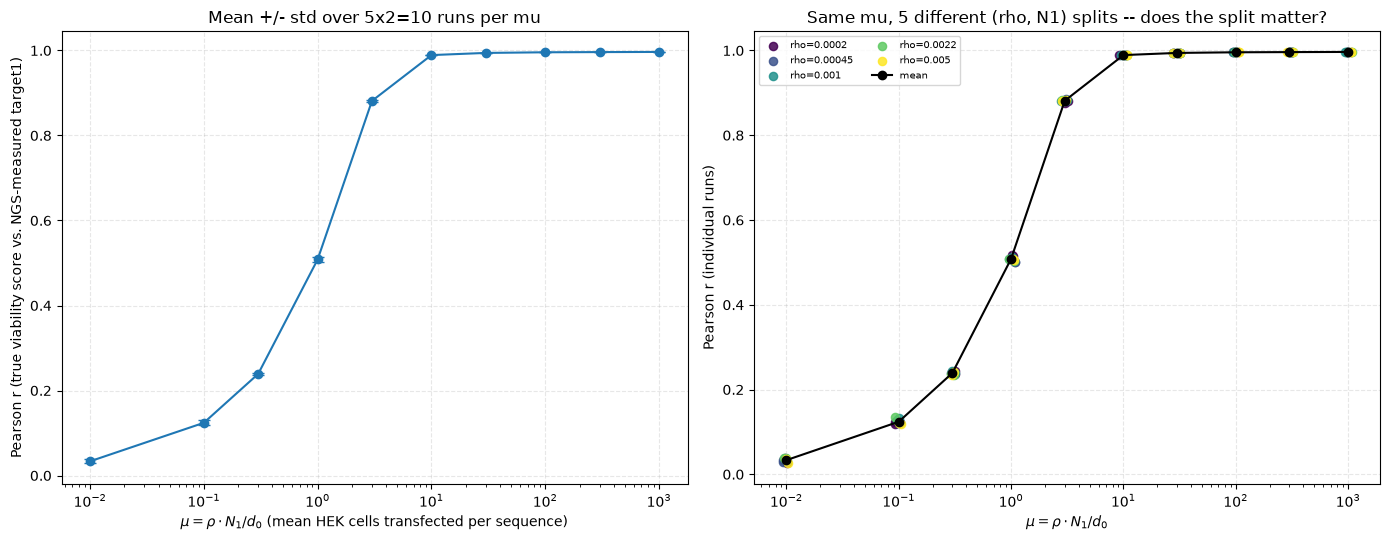

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.errorbar(summary_df["mu"], summary_df["r_mean"], yerr=summary_df["r_std"],
            marker="o", capsize=4, color="tab:blue", linestyle="-")
ax.set_xscale("log")
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$ (mean HEK cells transfected per sequence)")
ax.set_ylabel("Pearson r (true viability score vs. NGS-measured target1)")
ax.set_title(f"Mean +/- std over {len(RHO_SCALES)}x{N_REPEATS}={len(RHO_SCALES) * N_REPEATS} runs per mu")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
rng_jitter = np.random.default_rng(0)
cmap = plt.get_cmap("viridis", len(RHO_SCALES))
for i, rho_k in enumerate(RHO_REF * RHO_SCALES):
    sub = records_df[np.isclose(records_df["rho"], rho_k)]
    jitter = rng_jitter.uniform(0.92, 1.08, size=len(sub))
    ax.scatter(sub["mu"] * jitter, sub["r"], color=cmap(i), s=35, alpha=0.85,
               label=f"rho={rho_k:.2g}")
ax.plot(summary_df["mu"], summary_df["r_mean"], color="black", marker="o", lw=1.5, label="mean")
ax.set_xscale("log")
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$")
ax.set_ylabel("Pearson r (individual runs)")
ax.set_title("Same mu, 5 different (rho, N1) splits -- does the split matter?")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


## 6. How to read this

- If the right panel's 5 colors land on top of each other at every `mu` (tight vertical spread
  per `mu`), that confirms `mu` alone determines the outcome -- `rho` and `N1` only matter
  through their product, not individually. A systematic color ordering within a `mu` column
  (e.g. always low-`rho` above high-`rho`) would instead mean the split itself matters, and `mu`
  is not a sufficient summary.
- The left panel's overall shape is the actual answer to "does more HEK cells per sequence help":
  `r` should climb from a low, noisy baseline at small `mu` (few, noisy per-cell draws -- weak
  law-of-large-numbers averaging in `produce_capsids`) toward a plateau at large `mu` -- NOT all
  the way to 1, since sequencing depth (`D`), dilution (`dilution_factor`) and NB dispersion
  (`phi`) are held fixed throughout this sweep and impose their own noise floor on `target1`
  independent of `mu`.
- This isolates the PRODUCTION step only (`target1`, `lambda0p` -> `lambda2p`) -- the selectivity
  step downstream has its own noise sources (`noise_sel`, `T_sel`) untouched by `mu`, so this
  result doesn't directly say how `mu` affects the FINAL `lambda4`/selectivity readout, only the
  viability measurement that feeds into it.


## 7. Top-1000 recovery on a held-out test set: GT vs protocol vs MLP

Everything above compares `r` (Pearson correlation) between the noiseless GT viability score
and the NGS-measured `target1`, aggregated over the whole `mu` grid. This section asks a more
concrete question, at ONE fixed configuration -- the notebook's own baseline before section 3
starts overriding `protocol.N1`/`protocol._rho` (`rho=1e-3`, `N1=5e8`, i.e. `mu=25.00`, not
swept): half the fixed 20,000-sequence pool is held out as a test set, a `ProfileMLP` is trained
on the other half's NGS-measured `target1`, and then -- on the test fold only -- how much do the
"top-K best variants" sets agree across the three views of viability available here: the
noiseless GT score, the NGS-measured `target1` from ONE protocol run, and the MLP's prediction?

`K=1000` to start (10% of the 10,000-sequence test fold, the same top-10% convention used
elsewhere in this project) -- an easy knob to revisit at other `mu` levels later.

### 7.1 Setup: extra imports, train/test split

In [ ]:
from sklearn.model_selection import train_test_split
from flax import nnx
import optax

K_TOPK = 1000

X_all = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences)].reshape(N, -1)
idx_train, idx_test = train_test_split(np.arange(N), test_size=0.3, random_state=0)
X_train_full, X_test = X_all[idx_train], X_all[idx_test]
viab_score_test = viab_score[idx_test]

print(f"pool: {N:,}   train: {len(idx_train):,}   test: {len(idx_test):,}   "
      f"top-{K_TOPK} = top-{100 * K_TOPK / len(idx_test):.1f}% of the test set")

pool: 50,000   train: 25,000   test: 25,000   top-1000 = top-4.0% of the test set


### 7.2 Baseline protocol run: NGS-measured `target1` for train/test

Resets `protocol.N1`/`protocol._rho` to the baseline captured in section 3 (`original_N1`,
`original_rho`) -- section 3's sweep already restores them via its `finally` block, so this is
belt-and-suspenders -- then runs ONE fresh `loop_DE()` round (same reused `protocol` object and
advancing PRNG key as the rest of the notebook, so this is an independent draw, not a repeat of
any sweep run).

In [9]:
protocol.N1, protocol._rho = original_N1, original_rho
protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
_bio_row, ngs_row = protocol.loop_DE()
lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
target1_baseline = np.log((lambda2p + eps) / (lambda0p + eps))

target1_train = target1_baseline[idx_train]
target1_test  = target1_baseline[idx_test]

print(f"baseline protocol run (mu={original_rho * original_N1 / d0:.2f}) -- "
      f"r(GT, protocol) on test fold = {pearson(viab_score_test, target1_test):.3f}")

baseline protocol run (mu=10.00) -- r(GT, protocol) on test fold = 0.989


### 7.3 `ProfileMLP`: same architecture/training convention as the sibling notebooks

Identical `ProfileMLP` (Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head)
and `train_profile_mlp` (warmup-cosine-decay AdamW, early stopping on val MSE) as e.g.
`MLP_viability_noise_denoising50K.ipynb` -- trained here on the train fold's `target1` only.

In [10]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]

In [11]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f}")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    return model, best_val

In [12]:
Xtr, ytr, Xva, yva = split_train_val(X_train_full, target1_train, val_frac=0.15, seed=0)
print(f"train/val split: {Xtr.shape[0]:,} / {Xva.shape[0]:,}")

model, best_val = train_profile_mlp(Xtr, ytr, Xva, yva, epochs=300, patience=20, verbose=True)
print(f"best val MSE = {best_val:.4f}")

mlp_pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))

train/val split: 21,250 / 3,750
  early stop at epoch 126, best val MSE = 0.4033
best val MSE = 0.4033


### 7.4 Top-1000 recovery: GT vs protocol vs MLP

`topk_recovery(score_a, score_b, k)` (`analysisV1.py`) -- fraction of the absolute top-`k` (by
`score_a`) that are also in the top-`k` (by `score_b`); symmetric, so it applies the same way to
all three pairs even though only one of them (GT) is an actual ground truth.

In [13]:
rec_gt_protocol  = topk_recovery(viab_score_test, target1_test,  k=K_TOPK)
rec_gt_mlp       = topk_recovery(viab_score_test, mlp_pred_test, k=K_TOPK)
rec_protocol_mlp = topk_recovery(target1_test,     mlp_pred_test, k=K_TOPK)

print(f"Top-{K_TOPK} recovery on the held-out test set (n={len(idx_test):,}):")
print(f"  GT <-> protocol  : {100 * rec_gt_protocol:.1f}%")
print(f"  GT <-> MLP       : {100 * rec_gt_mlp:.1f}%")
print(f"  protocol <-> MLP : {100 * rec_protocol_mlp:.1f}%")

Top-1000 recovery on the held-out test set (n=25,000):
  GT <-> protocol  : 85.4%
  GT <-> MLP       : 83.5%
  protocol <-> MLP : 79.0%


### 7.5 Visual check: the three top-K recovery scatters

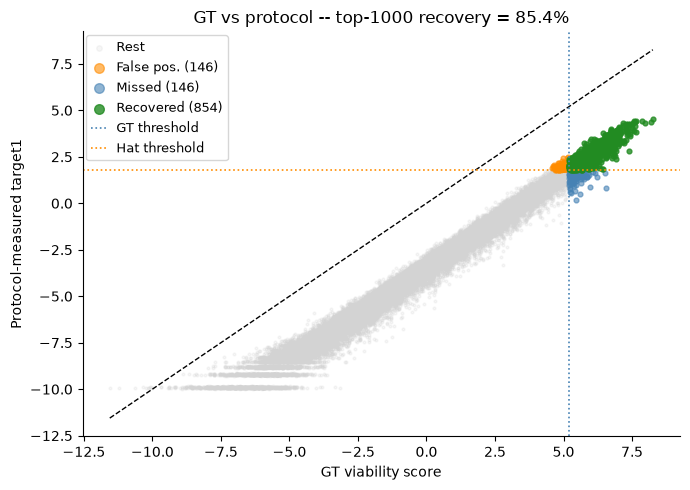

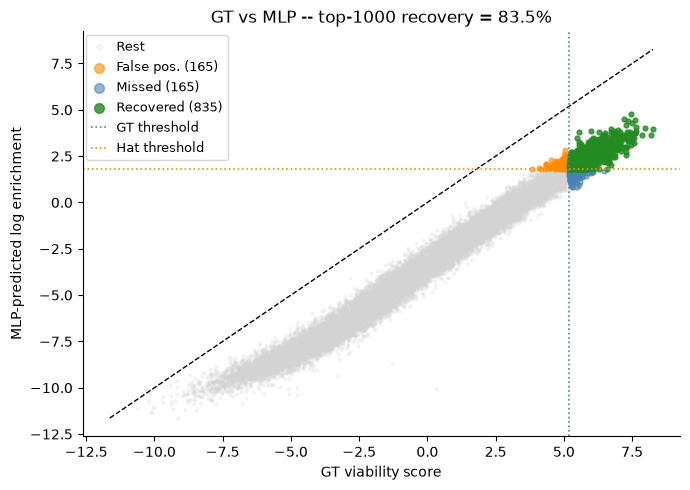

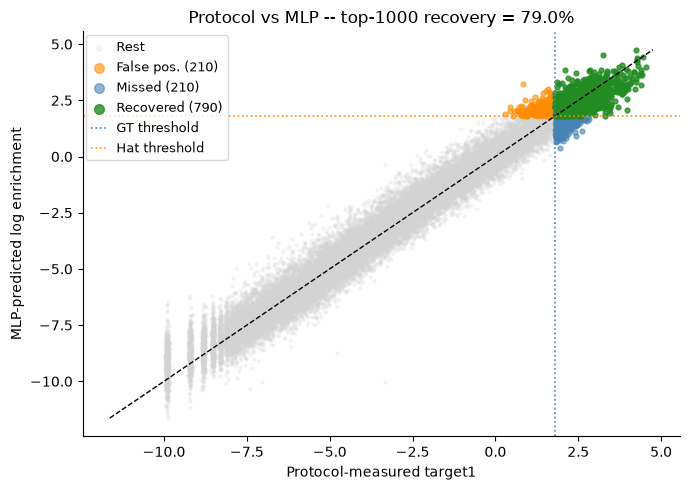

In [14]:
k_frac_test = K_TOPK / len(idx_test)

plot_topk_recovery(viab_score_test, target1_test, k_frac=k_frac_test,
                    title=f"GT vs protocol -- top-{K_TOPK} recovery = {100 * rec_gt_protocol:.1f}%",
                    xlabel="GT viability score", ylabel="Protocol-measured target1")
plt.show()

plot_topk_recovery(viab_score_test, mlp_pred_test, k_frac=k_frac_test,
                    title=f"GT vs MLP -- top-{K_TOPK} recovery = {100 * rec_gt_mlp:.1f}%",
                    xlabel="GT viability score", ylabel="MLP-predicted log enrichment")
plt.show()

plot_topk_recovery(target1_test, mlp_pred_test, k_frac=k_frac_test,
                    title=f"Protocol vs MLP -- top-{K_TOPK} recovery = {100 * rec_protocol_mlp:.1f}%",
                    xlabel="Protocol-measured target1", ylabel="MLP-predicted log enrichment")
plt.show()

### 7.6 Top-K recovery vs `mu`: does more HEK cells also help the MLP?

Section 7.1-7.4 only checked ONE fixed configuration (the baseline `mu=25.00`). This repeats
that same recipe -- train/test split fixed once (`idx_train`/`idx_test`/`X_train_full`/`X_test`
from 7.1), one fresh `loop_DE()` NGS run + one freshly trained `ProfileMLP` per point -- across
the SAME `MU_GRID` used by the correlation sweep in section 3, at a single `(rho, N1)` per `mu`
(`rho=RHO_REF`, `N1 = mu * d0 / RHO_REF` -- no averaging over the 5 rho-splits/2-repeats section 3
uses, to keep 8 full MLP trainings affordable). `protocol.N1`/`protocol._rho` are restored to the
baseline afterward, same `finally` pattern as section 3.

In [15]:
mu_sweep_records = []
target1_test_by_mu = {}
preds_mlp_by_mu    = {}

try:
    for mu in tqdm(MU_GRID, desc="mu sweep (top-K recovery)"):
        N1_mu = mu * d0 / RHO_REF
        protocol.N1      = float(N1_mu)
        protocol._rho    = float(RHO_REF)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1_mu = np.log((lambda2p + eps) / (lambda0p + eps))
        target1_train_mu, target1_test_mu = target1_mu[idx_train], target1_mu[idx_test]

        Xtr_mu, ytr_mu, Xva_mu, yva_mu = split_train_val(X_train_full, target1_train_mu,
                                                          val_frac=0.15, seed=0)
        model_mu, val_mu = train_profile_mlp(Xtr_mu, ytr_mu, Xva_mu, yva_mu,
                                              epochs=300, patience=20, verbose=False)
        pred_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_test)))

        rec_gt_protocol_mu  = topk_recovery(viab_score_test, target1_test_mu, k=K_TOPK)
        rec_gt_mlp_mu       = topk_recovery(viab_score_test, pred_mu,          k=K_TOPK)
        rec_protocol_mlp_mu = topk_recovery(target1_test_mu, pred_mu,          k=K_TOPK)

        mu_sweep_records.append(dict(mu=mu, rec_gt_protocol=rec_gt_protocol_mu,
                                      rec_gt_mlp=rec_gt_mlp_mu,
                                      rec_protocol_mlp=rec_protocol_mlp_mu))
        target1_test_by_mu[mu] = target1_test_mu
        preds_mlp_by_mu[mu]    = pred_mu
finally:
    protocol.N1, protocol._rho = original_N1, original_rho

mu_sweep_df = pd.DataFrame(mu_sweep_records)
mu_sweep_df

mu sweep (top-K recovery): 100%|██████████| 10/10 [07:48<00:00, 46.88s/it]


,mu,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp
0,0.01,0.041,0.077,0.045
1,0.10,0.078,0.118,0.091
2,0.30,0.283,0.238,0.150
3,1.00,0.572,0.375,0.315
4,3.00,0.739,0.597,0.525
5,10.00,0.857,0.831,0.778
6,30.00,0.908,0.852,0.823
7,100.00,0.952,0.856,0.854
8,300.00,0.971,0.858,0.858
9,1000.00,0.982,0.856,0.856


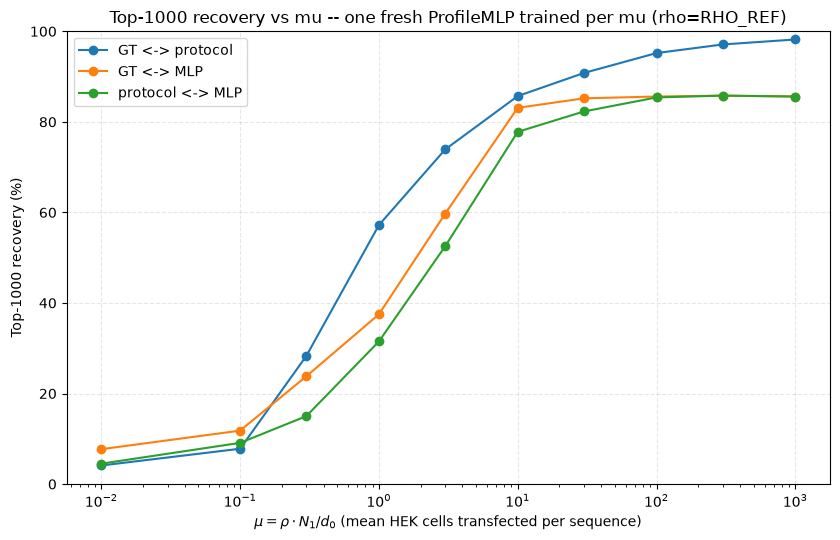

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$ (mean HEK cells transfected per sequence)")
ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
ax.set_title(f"Top-{K_TOPK} recovery vs mu -- one fresh ProfileMLP trained per mu (rho=RHO_REF)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

### 7.7 Best vs worst `mu`: the three recovery views side by side

Ranked by `rec_gt_mlp` (GT <-> MLP top-K recovery -- the metric that matters in practice, since
the MLP's own ranking is what actually gets used to pick candidate variants). Re-plots the same
three scatter panels as section 7.5, once for the `mu` with the highest recovery and once for the
lowest, so the effect of `mu` on all three pairwise views can be compared directly.

best mu  (highest GT<->MLP recovery): 300  (85.8%)
worst mu (lowest GT<->MLP recovery):  0.01  (7.7%)


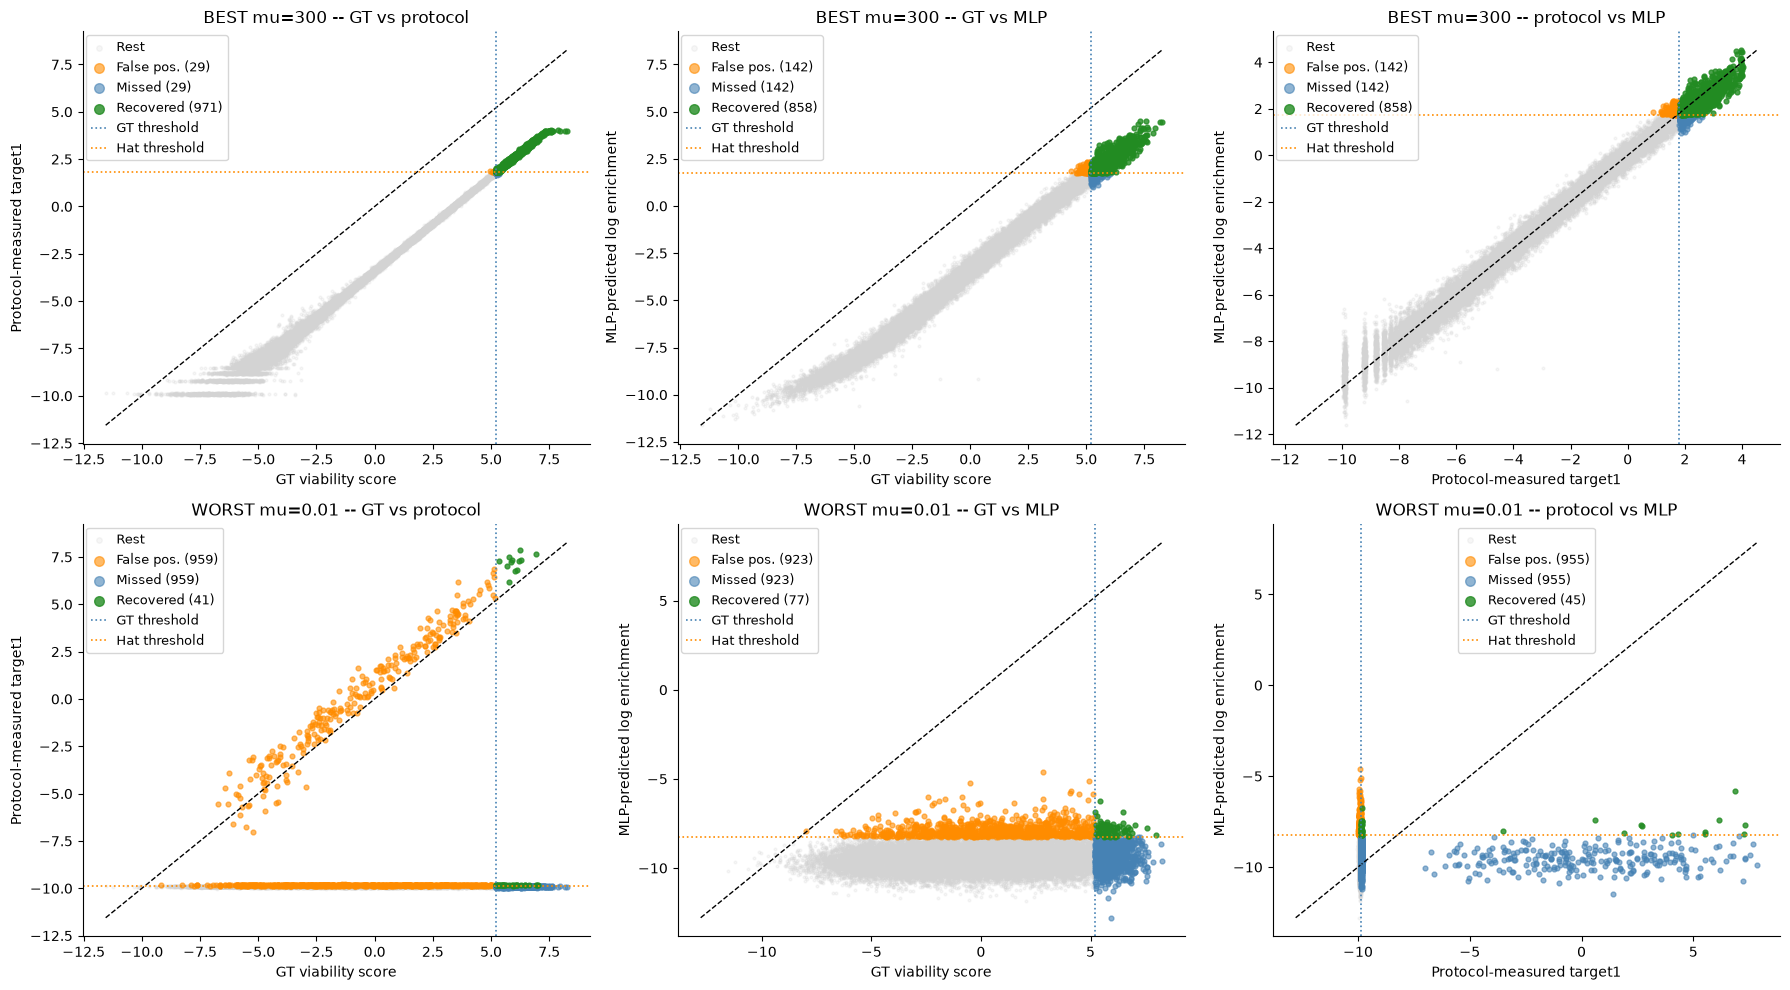

In [17]:
best_mu  = mu_sweep_df.loc[mu_sweep_df["rec_gt_mlp"].idxmax(), "mu"]
worst_mu = mu_sweep_df.loc[mu_sweep_df["rec_gt_mlp"].idxmin(), "mu"]
print(f"best mu  (highest GT<->MLP recovery): {best_mu:g}  "
      f"({100 * mu_sweep_df['rec_gt_mlp'].max():.1f}%)")
print(f"worst mu (lowest GT<->MLP recovery):  {worst_mu:g}  "
      f"({100 * mu_sweep_df['rec_gt_mlp'].min():.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (mu_sel, label) in enumerate([(best_mu, "BEST"), (worst_mu, "WORST")]):
    target1_sel = target1_test_by_mu[mu_sel]
    pred_sel    = preds_mlp_by_mu[mu_sel]

    plot_topk_recovery(viab_score_test, target1_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g} -- GT vs protocol",
                        xlabel="GT viability score", ylabel="Protocol-measured target1",
                        ax=axes[row, 0])
    plot_topk_recovery(viab_score_test, pred_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g} -- GT vs MLP",
                        xlabel="GT viability score", ylabel="MLP-predicted log enrichment",
                        ax=axes[row, 1])
    plot_topk_recovery(target1_sel, pred_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g} -- protocol vs MLP",
                        xlabel="Protocol-measured target1", ylabel="MLP-predicted log enrichment",
                        ax=axes[row, 2])
fig.tight_layout()
plt.show()

## 8. No noise: how much of the imperfect recovery is `noise_viab`/`noise_sel`, and how much is inherent sampling stochasticity?

Section 7 always used the constructor's `noise_viab=0.5`, `noise_sel=0.5` (Gaussian noise added
to the per-sequence score before the Poisson capsid-count draw / infection step). This repeats
section 7.6/7.7's exact recipe with `protocol.noise_viab = protocol.noise_sel = 0.0` instead
(restored afterward, same pattern as `original_N1`/`original_rho`) -- `MU_GRID`, `RHO_REF`, the
train/test split and `K_TOPK` all stay identical, so the two curves are directly comparable.

Removing `noise_viab`/`noise_sel` does NOT make the simulation deterministic: the Poisson
capsid-count draw in `produce_capsids` and the NGS read-depth negative-binomial sampling are
still there regardless. If the curve below still falls short of 100% at large `mu`, that gap
isn't `noise_viab` -- it's `mu`-driven undersampling and/or NGS depth (`D`).

### 8.1 Top-K recovery vs `mu`, no noise

In [18]:
original_noise_viab, original_noise_sel = protocol.noise_viab, protocol.noise_sel

mu_sweep_nonoise_records    = []
target1_test_nonoise_by_mu  = {}
preds_mlp_nonoise_by_mu     = {}

try:
    protocol.noise_viab = 0.0
    protocol.noise_sel  = 0.0
    for mu in tqdm(MU_GRID, desc="mu sweep, no noise (top-K recovery)"):
        N1_mu = mu * d0 / RHO_REF
        protocol.N1      = float(N1_mu)
        protocol._rho    = float(RHO_REF)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1_mu = np.log((lambda2p + eps) / (lambda0p + eps))
        target1_train_mu, target1_test_mu = target1_mu[idx_train], target1_mu[idx_test]

        Xtr_mu, ytr_mu, Xva_mu, yva_mu = split_train_val(X_train_full, target1_train_mu,
                                                          val_frac=0.15, seed=0)
        model_mu, val_mu = train_profile_mlp(Xtr_mu, ytr_mu, Xva_mu, yva_mu,
                                              epochs=300, patience=20, verbose=False)
        pred_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_test)))

        rec_gt_protocol_mu  = topk_recovery(viab_score_test, target1_test_mu, k=K_TOPK)
        rec_gt_mlp_mu       = topk_recovery(viab_score_test, pred_mu,          k=K_TOPK)
        rec_protocol_mlp_mu = topk_recovery(target1_test_mu, pred_mu,          k=K_TOPK)

        mu_sweep_nonoise_records.append(dict(mu=mu, rec_gt_protocol=rec_gt_protocol_mu,
                                              rec_gt_mlp=rec_gt_mlp_mu,
                                              rec_protocol_mlp=rec_protocol_mlp_mu))
        target1_test_nonoise_by_mu[mu] = target1_test_mu
        preds_mlp_nonoise_by_mu[mu]    = pred_mu
finally:
    protocol.N1, protocol._rho              = original_N1, original_rho
    protocol.noise_viab, protocol.noise_sel = original_noise_viab, original_noise_sel

mu_sweep_nonoise_df = pd.DataFrame(mu_sweep_nonoise_records)
mu_sweep_nonoise_df

mu sweep, no noise (top-K recovery): 100%|██████████| 10/10 [08:50<00:00, 53.01s/it]


,mu,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp
0,0.01,0.052,0.093,0.047
1,0.10,0.081,0.123,0.084
2,0.30,0.251,0.236,0.145
3,1.00,0.627,0.368,0.309
4,3.00,0.762,0.619,0.565
5,10.00,0.870,0.834,0.802
6,30.00,0.928,0.853,0.840
7,100.00,0.964,0.852,0.848
8,300.00,0.980,0.856,0.858
9,1000.00,0.980,0.853,0.857


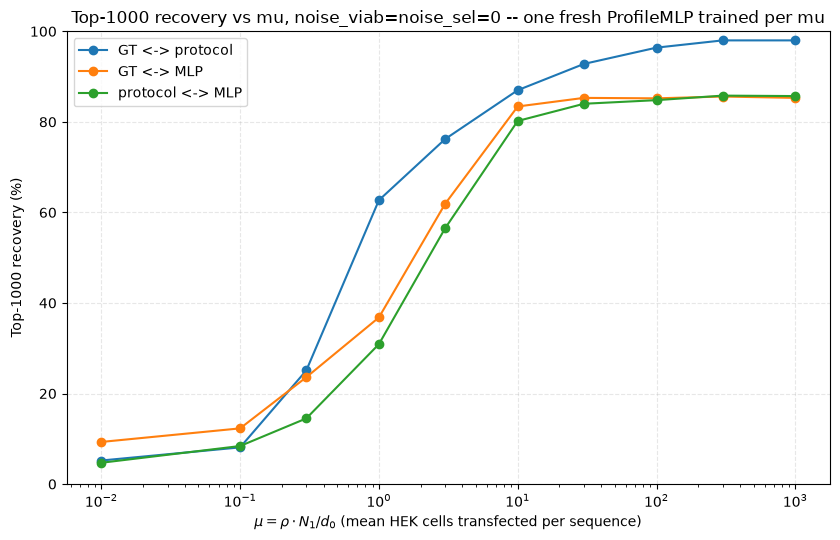

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(mu_sweep_nonoise_df["mu"], 100 * mu_sweep_nonoise_df["rec_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(mu_sweep_nonoise_df["mu"], 100 * mu_sweep_nonoise_df["rec_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(mu_sweep_nonoise_df["mu"], 100 * mu_sweep_nonoise_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$ (mean HEK cells transfected per sequence)")
ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
ax.set_title(f"Top-{K_TOPK} recovery vs mu, noise_viab=noise_sel=0 -- one fresh ProfileMLP trained per mu")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

### 8.2 Best vs worst `mu` (no noise): the three recovery views side by side

Same ranking convention as section 7.7 (by `rec_gt_mlp`), on the no-noise sweep from 8.1.

best mu  (highest GT<->MLP recovery, no noise): 300  (85.6%)
worst mu (lowest GT<->MLP recovery, no noise):  0.01  (9.3%)


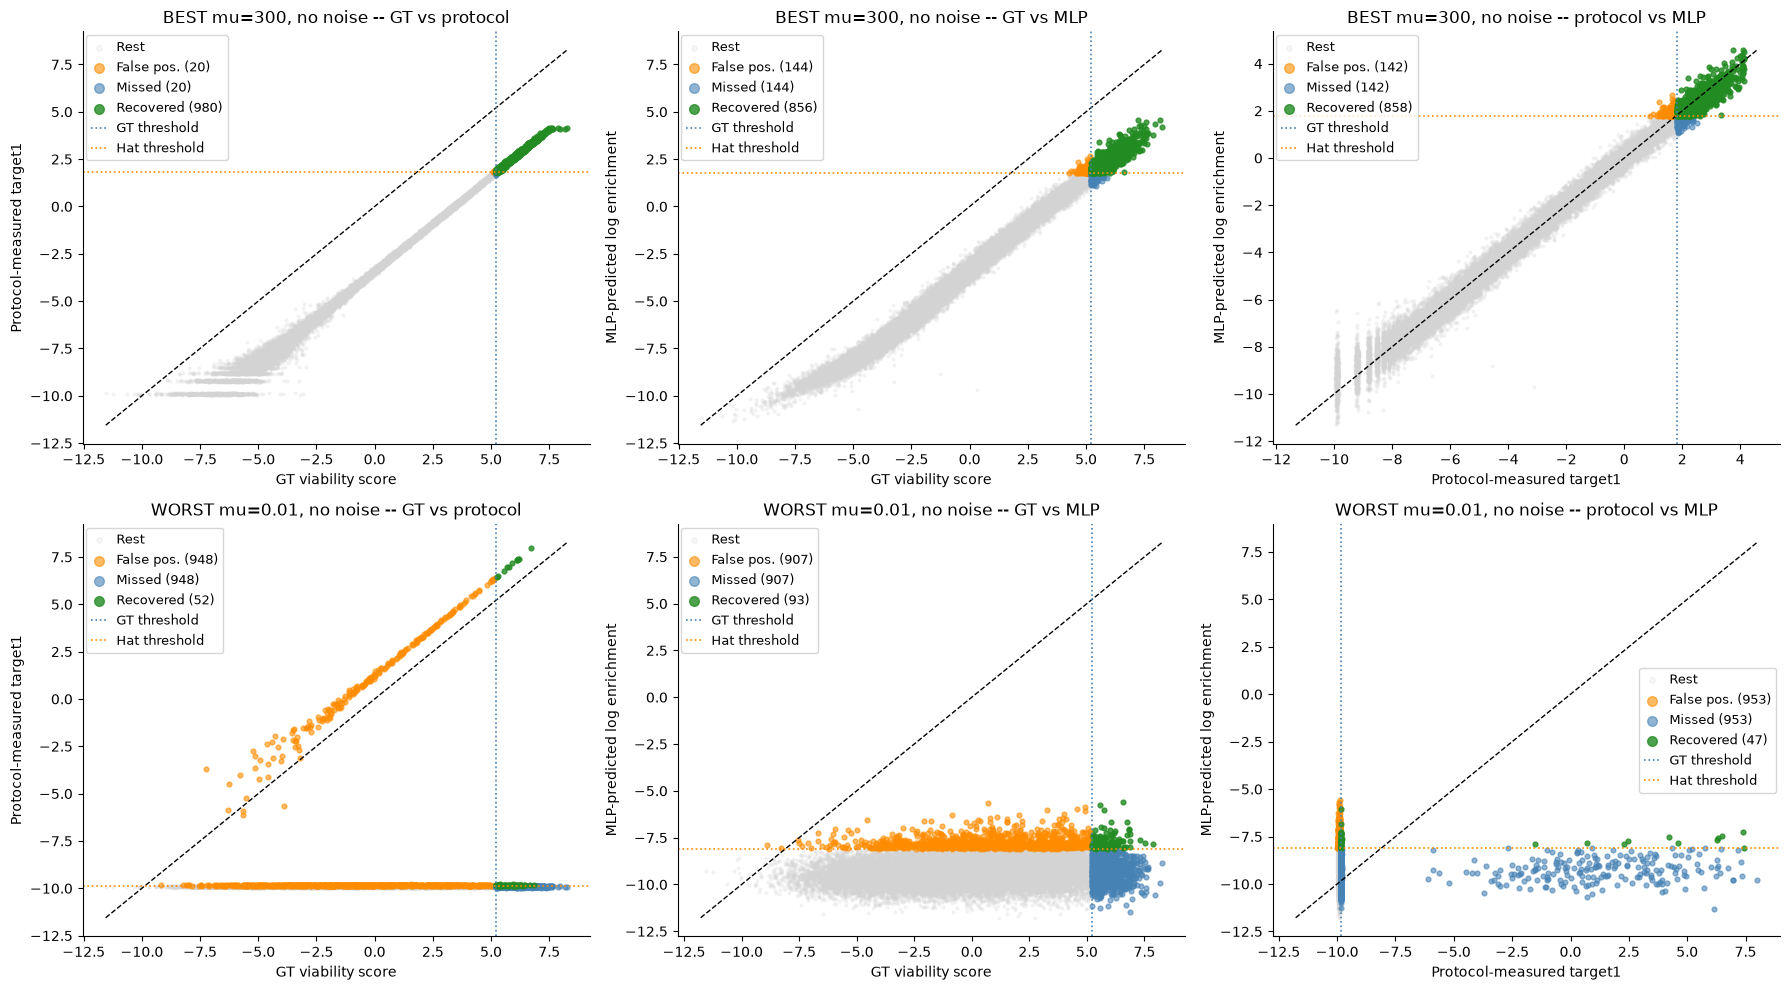

In [20]:
best_mu_nonoise  = mu_sweep_nonoise_df.loc[mu_sweep_nonoise_df["rec_gt_mlp"].idxmax(), "mu"]
worst_mu_nonoise = mu_sweep_nonoise_df.loc[mu_sweep_nonoise_df["rec_gt_mlp"].idxmin(), "mu"]
print(f"best mu  (highest GT<->MLP recovery, no noise): {best_mu_nonoise:g}  "
      f"({100 * mu_sweep_nonoise_df['rec_gt_mlp'].max():.1f}%)")
print(f"worst mu (lowest GT<->MLP recovery, no noise):  {worst_mu_nonoise:g}  "
      f"({100 * mu_sweep_nonoise_df['rec_gt_mlp'].min():.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (mu_sel, label) in enumerate([(best_mu_nonoise, "BEST"), (worst_mu_nonoise, "WORST")]):
    target1_sel = target1_test_nonoise_by_mu[mu_sel]
    pred_sel    = preds_mlp_nonoise_by_mu[mu_sel]

    plot_topk_recovery(viab_score_test, target1_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g}, no noise -- GT vs protocol",
                        xlabel="GT viability score", ylabel="Protocol-measured target1",
                        ax=axes[row, 0])
    plot_topk_recovery(viab_score_test, pred_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g}, no noise -- GT vs MLP",
                        xlabel="GT viability score", ylabel="MLP-predicted log enrichment",
                        ax=axes[row, 1])
    plot_topk_recovery(target1_sel, pred_sel, k_frac=k_frac_test,
                        title=f"{label} mu={mu_sel:g}, no noise -- protocol vs MLP",
                        xlabel="Protocol-measured target1", ylabel="MLP-predicted log enrichment",
                        ax=axes[row, 2])
fig.tight_layout()
plt.show()